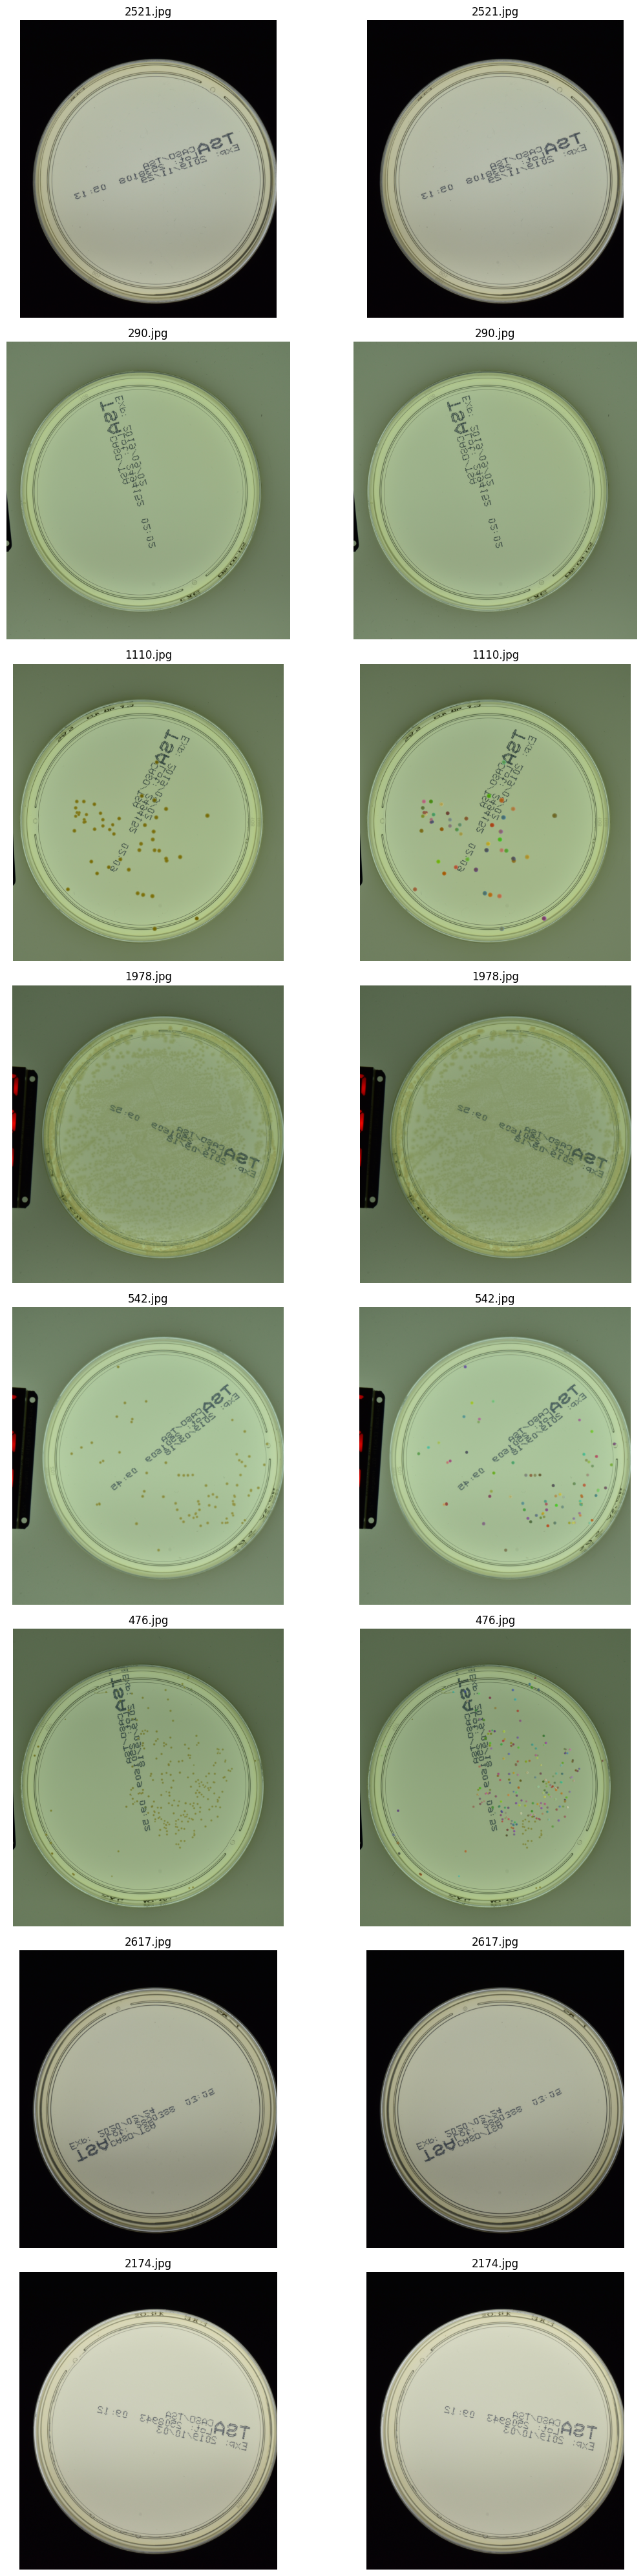

In [1]:
# Notebook-friendly YOLO-seg label visualiser (polygons -> instance masks overlay)
#
# Shows, for X random images:
#   [Original]  |  [Original + instance masks overlay]
# Titles are the image filenames.
#
# Assumes YOLO segmentation label format per line:
#   <class_id> x1 y1 x2 y2 x3 y3 ...  (normalized to [0,1], polygon points)
#
# Expected folder layout (common):
#   dataset/
#     images/   <-- IMAGE_FOLDER points here
#     labels/   <-- LABEL_FOLDER defaults to sibling "labels"
#
# If your labels are elsewhere, set LABEL_FOLDER explicitly below.

# -----------------------
# Inputs
# -----------------------
IMAGE_FOLDER = r"D:\AGAR_dataset\AGAR_dataset\yolo_dataset_split_1class_3way\images\train"
X = 8  # number of random images to view
LABEL_FOLDER = r"D:\AGAR_dataset\AGAR_dataset\yolo_dataset_split_1class_3way\labels\train"  # set to r"D:\path\to\dataset\labels" if not sibling of IMAGE_FOLDER

SEED = 0
ALPHA = 0.45  # overlay transparency (0-1)
MAX_INSTANCES_TO_DRAW = None  # e.g. 50 to cap, or None for all

# -----------------------
# Code
# -----------------------
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


def _default_label_folder(image_folder: Path) -> Path:
    """
    If IMAGE_FOLDER ends with 'images', use sibling 'labels'.
    Otherwise, use the same folder (expects labels next to images).
    """
    if image_folder.name.lower() == "images":
        return image_folder.parent / "labels"
    return image_folder


def list_images(folder: Path):
    imgs = [p for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS]
    if not imgs:
        raise FileNotFoundError(f"No images found under: {folder}")
    return imgs


def read_yolo_seg_label(label_path: Path):
    """
    Returns list of dicts:
      [{"cls": int, "poly_norm": np.ndarray shape (N,2)}]
    """
    instances = []
    if not label_path.exists():
        return instances  # no labels -> empty

    txt = label_path.read_text(encoding="utf-8").strip()
    if not txt:
        return instances

    for ln in txt.splitlines():
        ln = ln.strip()
        if not ln:
            continue
        parts = ln.split()
        if len(parts) < 1 + 6:  # cls + at least 3 points (x,y)*3
            continue

        cls = int(float(parts[0]))
        coords = np.array([float(x) for x in parts[1:]], dtype=np.float32)

        if coords.size % 2 != 0 or coords.size < 6:
            continue

        poly = coords.reshape(-1, 2)
        instances.append({"cls": cls, "poly_norm": poly})
    return instances


def polygon_to_mask(poly_xy: np.ndarray, w: int, h: int) -> np.ndarray:
    """
    poly_xy: (N,2) in pixel coords (float ok)
    Returns mask: (h,w) boolean
    Uses PIL rasterization (no OpenCV required).
    """
    img = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(img)

    # Convert to list of tuples; clip to image bounds for safety
    pts = []
    for x, y in poly_xy:
        x = float(np.clip(x, 0, w - 1))
        y = float(np.clip(y, 0, h - 1))
        pts.append((x, y))

    if len(pts) >= 3:
        draw.polygon(pts, outline=1, fill=1)

    return np.array(img, dtype=np.uint8).astype(bool)


def overlay_instance_masks(img_rgb: np.ndarray, masks: list, alpha: float = 0.45, seed: int = 0) -> np.ndarray:
    """
    img_rgb: (h,w,3) uint8
    masks: list of boolean (h,w)
    """
    if img_rgb.dtype != np.uint8:
        img_rgb = img_rgb.astype(np.uint8)

    h, w = img_rgb.shape[:2]
    out = img_rgb.copy()

    rng = np.random.default_rng(seed)

    # generate distinct-ish random colors
    colors = rng.integers(low=0, high=256, size=(len(masks), 3), dtype=np.uint8)

    for i, m in enumerate(masks):
        if m is None or m.shape != (h, w) or not m.any():
            continue
        color = colors[i]
        # alpha blend only where mask is True
        out[m] = (alpha * color + (1 - alpha) * out[m]).astype(np.uint8)

    return out


def visualise_random_yolo_seg(
    image_folder: str,
    x: int,
    label_folder: str | None = None,
    seed: int = 0,
    alpha: float = 0.45,
    max_instances_to_draw: int | None = None,
):
    image_folder = Path(image_folder)
    if not image_folder.exists():
        raise FileNotFoundError(f"IMAGE_FOLDER not found: {image_folder}")

    label_folder = Path(label_folder) if label_folder else _default_label_folder(image_folder)
    # label folder may not exist; we handle missing labels per-image
    # but warn if none exists
    if not label_folder.exists():
        print(f"Warning: LABEL_FOLDER does not exist: {label_folder} (will treat as no labels)")

    all_imgs = list_images(image_folder)
    random.seed(seed)
    chosen = random.sample(all_imgs, min(x, len(all_imgs)))

    n = len(chosen)
    fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, 5 * n))
    if n == 1:
        axes = np.array([axes])  # normalize to 2D indexable

    for row, img_path in enumerate(chosen):
        # Load image as RGB
        img = Image.open(img_path).convert("RGB")
        rgb = np.array(img, dtype=np.uint8)
        h, w = rgb.shape[:2]

        # Find label file by stem
        label_path = label_folder / (img_path.stem + ".txt")
        instances = read_yolo_seg_label(label_path)

        # Convert each polygon instance to mask
        masks = []
        for inst in instances:
            poly_norm = inst["poly_norm"]
            # normalized -> pixel coords
            poly_xy = np.empty_like(poly_norm)
            poly_xy[:, 0] = poly_norm[:, 0] * w
            poly_xy[:, 1] = poly_norm[:, 1] * h
            masks.append(polygon_to_mask(poly_xy, w=w, h=h))

        if max_instances_to_draw is not None:
            masks = masks[:max_instances_to_draw]

        overlay = overlay_instance_masks(rgb, masks, alpha=alpha, seed=seed + row)

        ax0, ax1 = axes[row, 0], axes[row, 1]
        ax0.imshow(rgb)
        ax0.set_title(img_path.name)
        ax0.axis("off")

        ax1.imshow(overlay)
        ax1.set_title(img_path.name)
        ax1.axis("off")

        if not instances:
            ax1.set_xlabel("No labels found", fontsize=10)

    plt.tight_layout()
    plt.show()


# Run it
visualise_random_yolo_seg(
    image_folder=IMAGE_FOLDER,
    x=X,
    label_folder=LABEL_FOLDER,
    seed=SEED,
    alpha=ALPHA,
    max_instances_to_draw=MAX_INSTANCES_TO_DRAW,
)
